In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [70]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

  # print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [71]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [169]:
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  X, Y = [], []
  for w in words:
  
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append
  
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [33]:
C = torch.randn((27,2 ))

In [34]:
emb = C[X] # torch can find the embedding vectors for each group in C and return a tensor # this if of size 32 x 3 x 2
emb.shape

torch.Size([32, 3, 2])

In [35]:
# 6 as we have 2 dimentional embedding and we have 3 of them as input (we use 3 chars to predict the 4th)
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [36]:
# combine the embeddings of each context in one input vector so we can multiply it to the weights
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape
# torch.cat(torch.unbind(emb, 1), 1).shape
# emb.view(32,6)

h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # h is the activations for every one of our inputs, when -1 is used, pytorch will derive the needed value
h.size()

torch.Size([32, 100])

In [37]:
h

tensor([[ 0.9998, -0.9948, -0.9772,  ..., -0.9712, -0.9198,  0.8079],
        [ 0.9998, -0.9441, -0.8666,  ..., -0.9995, -0.5235, -0.9150],
        [ 0.9964, -0.8890, -0.5314,  ..., -0.9963, -0.7836, -0.0711],
        ...,
        [ 0.9938, -0.9998, -0.9910,  ...,  0.1736, -0.9997,  1.0000],
        [ 0.9911, -0.9995, -0.6482,  ..., -0.9747,  0.2496,  0.5930],
        [ 1.0000,  0.9989, -0.8615,  ..., -0.9970, -0.9848, -0.9993]])

In [38]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [39]:
logits = h @ W2 + b2

In [41]:
logits.shape

torch.Size([32, 27])

In [42]:
counts = logits.exp()

In [43]:
prob = counts / counts.sum(1, keepdims=True)

In [44]:
prob.shape

torch.Size([32, 27])

In [49]:
prob[0].sum()

tensor(1.)

In [53]:
# prob assigned by the nn to the correct character for each sequence
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(16.6729)

In [60]:
# ---- thigs till now in one place ----------------

In [183]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182580, 3]), torch.Size([182580]))

In [254]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [255]:
sum(p.nelement() for p in parameters) # number of parameters in total

17697

In [256]:
for p in parameters:
  p.requires_grad = True

In [257]:
# learning rate sweep candidates. searching between 0.001 and 1
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [258]:
lri = []
lossi = []
stepi = []

In [263]:

for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32, ))
  
  # Forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  # counts = logits.exp()
  # prob = counts / counts.sum(1, keepdims=True)
  # loss = -prob[torch.arange(32), Y].log().mean()
  loss = F.cross_entropy(logits, Ytr[ix])
  
  # Backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # Update
  # lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

print(loss.item())

2.1373980045318604


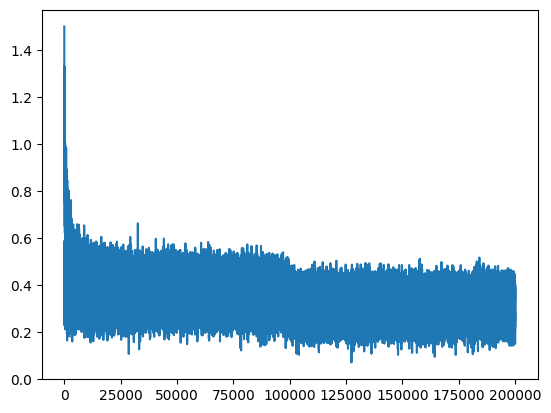

In [264]:
#plt.plot(lri, lossi)
# plt.plot(stepi, lossi)
plt.plot(stepi, lossi)

In [265]:
# DEV LOSS
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1318, grad_fn=<NllLossBackward0>)

In [266]:
# TRAINING SET LOSS
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0568, grad_fn=<NllLossBackward0>)

In [239]:
# visualizing the 2 dimentional embedding vectors for inputs
# plt.figure(figsize=(8, 8))
# plt.scatter(C[:,0].data, C[:,1].data, s=200)
# for i in range(C.shape[0]):
#   plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
# plt.grid('minor')

In [281]:
# Sampling from the model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

  out = []
  context = [0] * block_size # initialize with all ...
  while True:
    emb = C[torch.tensor([context])] # 1, block_size_d
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

chrish.
amelle.
khy.
miliathty.
halaysa.
jazon.
nayverynt.
kaeli.
nellara.
chaiiv.
kaleigh.
ham.
joce.
quinthonova.
alianni.
watell.
dearixi.
jaxen.
dus.
brex.
